# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [178]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

from scipy.stats import wilcoxon, ranksums
from numpy import matlib
from scipy.stats.distributions import chi2
from sklearn.model_selection import KFold

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [4]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [1689]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        running_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(intermediate=False, ci=True)
    for j in range(len(model.basis_list)):
        running_output[i,j-1] = output_list[j]
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        stationary_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(intermediate=False, ci=True)
    for j in range(len(model.basis_list)):
        stationary_output[i,j-1] = output_list[j]
    

6it [01:55, 19.21s/it]


## Getting Gaussian bumps as ground truth current

In [1298]:
# A simplestest current generator with moving bumps
def getI(features, dt, nt, npadding):
    
    time_line = np.arange(-npadding, nt)*dt
    baseline = features["baseline"]
    features["I"] = np.zeros((len(time_line), features["bump_center"][0].shape[0]))+baseline
    for i in range(len(features["bump_amp"])):
        stimulus = (features["bump_amp"][i])*np.exp(-((time_line[:, np.newaxis]- \
                       features["bump_center"][i][np.newaxis, :])/features["bump_wid"][i])**2)
        features["I"] += stimulus

In [1643]:
# Current generator with moving bumps but using time warping to move
def getI(features, dt, nt, npadding):
    time_line = np.arange(-npadding, nt)*dt
    baseline = features["baseline"]
    stimulus = np.zeros((len(time_line), features["bump_center"][0].shape[0]))
    
    stimulus_pre = np.zeros(nt+npadding)
    for i in range(len(features["bump_amp"])):
        stimulus_pre += (features["bump_amp"][i])*np.exp(-((time_line- \
                       features["bump_pre_center"][i])/features["bump_wid"][i])**2)

    for itrial in range(features["bump_center"][0].shape[0]):
        stimulus[:,itrial] =  GLM.linear_time_warping_single(time_line, stimulus_pre, 
            [0, features["bump_pre_center"][0], 150], [0, features["bump_center"][0][itrial], 150])
        stimulus[:,itrial] =  GLM.linear_time_warping_single(time_line, stimulus[:,itrial], 
            [150, features["bump_pre_center"][1], 350], [150, features["bump_center"][1][itrial], 350])
    
    features["I"] = stimulus+baseline
    features["I_pre"] = stimulus_pre

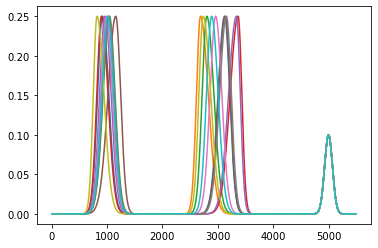

In [1648]:
ntrial = 50
source = {"baseline": 0, 
          "bump_pre_center": [50,250], 
          "bump_amp": [0.25,0.25], 
          "bump_wid": [15,15],
          "bump_center": np.nan}
std1 = 10
corr1 = 0.8
std2 = 20
corr2 = 0.8
bump_center_mean1 = [50, 70]
bump_center_cov1 = np.array([[std1**2, corr1*std1**2], [corr1*std1**2, std1**2]])
#     bump_center_cov1 = np.array([[0, 0], [0, 0]])
bump_center_mean2 = [250, 260]
bump_center_cov2 = np.array([[std2**2, corr2*std2**2], [corr2*std2**2, std2**2]])
#     bump_center_cov2 = np.array([[0, 0], [0, 0]])
bump_centers1 = np.random.multivariate_normal(bump_center_mean1, bump_center_cov1, size=ntrial)
bump_centers2 = np.random.multivariate_normal(bump_center_mean2, bump_center_cov2, size=ntrial)
source["bump_center"] = [bump_centers1[:, 0], bump_centers2[:, 0]]
target["bump_center"] = [bump_centers1[:, 1], bump_centers2[:, 1]]

getI(source, 0.1, 5000, 500, True)
plt.plot(source["I"][:,:10])

## Getting input current from real data

In [1767]:
# Current generator using real log firing rate
# Only need "bump_pre_center" and "bump_center"
def getI_real_data(features, dt, nt, npadding, log_fr):
    padding = int(dt*npadding)
    time_line = np.arange(-npadding, nt)*dt
    baseline = log_fr[0]
    log_fr = np.concatenate((np.ones(padding)*baseline,log_fr))
    old_time_line = np.arange(-padding, -padding+len(log_fr))
    stimulus_pre = np.interp(time_line, old_time_line, log_fr)
    
    stimulus = np.zeros((len(time_line), features["bump_center"][0].shape[0]))
    for itrial in range(features["bump_center"][0].shape[0]):
        stimulus[:,itrial] =  GLM.linear_time_warping_single(time_line, stimulus_pre, 
            [0, features["bump_pre_center"][0], 150], [0, features["bump_center"][0][itrial], 150])
        stimulus[:,itrial] =  GLM.linear_time_warping_single(time_line, stimulus[:,itrial], 
            [150, features["bump_pre_center"][1], 350], [150, features["bump_center"][1][itrial], 350])
    stimulus = np.exp(stimulus)
    I_max = features["bump_amp"]
    I_min = features["baseline"]
    stimulus = (stimulus-stimulus.min())/(stimulus.max()-stimulus.min())*(I_max-I_min) + I_min
    features["I"] = stimulus
    features["I_pre"] = stimulus_pre

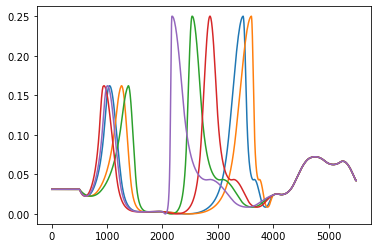

In [1769]:
ntrial = 100
source = {"bump_pre_center": [stationary_model_list[2].shifts[0,0]*1e3,stationary_model_list[2].shifts[0,2]*1e3], 
          "bump_center": np.nan,
          "bump_amp": 0.25,
          "baseline": 0}
std1 = 15
corr1 = 0.8
std2 = 35
corr2 = 0.8
bump_center_mean1 = [60, 70]
bump_center_cov1 = np.array([[std1**2, corr1*std1**2], [corr1*std1**2, std1**2]])
#     bump_center_cov1 = np.array([[0, 0], [0, 0]])
bump_center_mean2 = [240, 250]
bump_center_cov2 = np.array([[std2**2, corr2*std2**2], [corr2*std2**2, std2**2]])
#     bump_center_cov2 = np.array([[0, 0], [0, 0]])
bump_centers1 = np.random.multivariate_normal(bump_center_mean1, bump_center_cov1, size=ntrial)
bump_centers2 = np.random.multivariate_normal(bump_center_mean2, bump_center_cov2, size=ntrial)
source["bump_center"] = [bump_centers1[:, 0], bump_centers2[:, 0]]
target["bump_center"] = [bump_centers1[:, 1], bump_centers2[:, 1]]

getI_real_data(source, 0.1, 5000, 500, stationary_model_list[2].get_filter()[0])
plt.plot(source["I"][:,:5])

## EIF simulation function

In [2081]:
# Store for multiprocessing
EIF_params = {"V1_pre_center_p1":stationary_model_list[2].shifts[0,0]*1e3,
         "V1_pre_center_p2":stationary_model_list[2].shifts[0,2]*1e3,
         "LM_pre_center_p1":stationary_model_list[3].shifts[0,0]*1e3,
         "LM_pre_center_p2":stationary_model_list[3].shifts[0,2]*1e3,
         "V1_template":stationary_model_list[2].get_filter()[0],
         "LM_template":stationary_model_list[3].get_filter()[0]}

with open('EIF_params.pickle', 'wb') as handle:
    pickle.dump(EIF_params, handle)

with open('EIF_params.pickle', 'rb') as handle:
    EIF_params = pickle.load(handle)

In [2091]:
def EIF_simulator(std1=10, corr1=0.5, std2=25, corr2=0.9, ntrial=100, conn=0.0, return_current=False):
#     ntrial = 100
    nneuron = 20
    dt = 0.1
    ndt = int(1/dt)
    padding = 50
    nt = (500)*ndt
    padding = 50
    npadding = padding*ndt
    nt_tot = nt + npadding
    noise_amp = 1.0

    J = np.zeros((nneuron, nneuron)) # From row i to column j
    nneuron_part = int(nneuron/2)
    J[0:nneuron_part,nneuron_part:] = conn
    J[0:nneuron_part,0:nneuron_part] = 0.0
    J[nneuron_part:,nneuron_part:] = 0.0

    baseline = 0.0
    bump_amp = 0.25
    bump_wid = 10
#     std1 = 10
#     corr1 = 0.5
#     std2 = 25
#     corr2 = 0.9
    bump_center_mean1 = [60, 65]
    bump_center_cov1 = np.array([[std1**2, corr1*std1**2], [corr1*std1**2, std1**2]])
    bump_center_mean2 = [260, 265]
    bump_center_cov2 = np.array([[std2**2, corr2*std2**2], [corr2*std2**2, std2**2]])
    bump_centers1 = np.random.multivariate_normal(bump_center_mean1, bump_center_cov1, size=ntrial)
    bump_centers2 = np.random.multivariate_normal(bump_center_mean2, bump_center_cov2, size=ntrial)
    bump_centers1[bump_centers1>=130] = 130
    bump_centers1[bump_centers1<=10] = 10
    bump_centers2[bump_centers2>=330] = 330
    bump_centers2[bump_centers2<=170] = 170
    
#     source = {"baseline": baseline, 
#               "bump_pre_center": [bump_center_mean1[0],bump_center_mean2[0]], 
#               "bump_center": [np.nan,np.nan], 
#               "bump_amp": [bump_amp,bump_amp], 
#               "bump_wid": [bump_wid,bump_wid]}
# #               "bump_amp": [0.15,0.25], 
# #               "bump_wid": [20,10]}
#     target = {"baseline": baseline, 
#               "bump_pre_center": [bump_center_mean1[1],bump_center_mean2[1]], 
#               "bump_center": [np.nan,np.nan], 
#               "bump_amp": [bump_amp,bump_amp], 
#               "bump_wid": [bump_wid,bump_wid]}
# #               "bump_amp": [0.2,0.2], 
# #               "bump_wid": [15,15]}
#     source["bump_center"] = [bump_centers1[:, 0], bump_centers2[:, 0]]
#     target["bump_center"] = [bump_centers1[:, 1], bump_centers2[:, 1]]
#     getI(source, dt, nt, npadding, False)
#     getI(target, dt, nt, npadding, False)
    
    source = {"bump_pre_center": [stationary_model_list[2].shifts[0,0]*1e3,
                                  stationary_model_list[2].shifts[0,2]*1e3], 
              "bump_center": np.nan, 
              "baseline": baseline, 
              "bump_amp": bump_amp }
    target = {"bump_pre_center": [stationary_model_list[3].shifts[0,0]*1e3,
                                  stationary_model_list[3].shifts[0,2]*1e3], 
              "bump_center": np.nan, 
              "baseline": baseline, 
              "bump_amp": bump_amp }
    source["bump_center"] = [bump_centers1[:, 0], bump_centers2[:, 0]]
    target["bump_center"] = [bump_centers1[:, 1], bump_centers2[:, 1]]
    getI_real_data(source, dt, nt, npadding, stationary_model_list[2].get_filter()[0])
    getI_real_data(target, dt, nt, npadding, stationary_model_list[3].get_filter()[0])

    I_ext = 0.0*np.ones((nt_tot, nneuron, ntrial))
    I_ext[:,:nneuron_part,:] = np.repeat(source["I"][:,np.newaxis,:],nneuron_part, axis=1)
    I_ext[:,nneuron_part:,:] = np.repeat(target["I"][:,np.newaxis,:],nneuron_part, axis=1)
#     I_ext += np.random.normal(0,10,I_ext.shape)

    # Unit: mV or ms
    tau = 15
    EL = -60
    VT = -50
    Vth = -10
    Vre = -65
    DltT = 2
    tau_ref = 1
    tau_d = 5
    tau_r = 1

    nsyn_func = 3*tau_d*ndt
    syn_time_line = np.arange(nsyn_func)
    syn_func = (np.exp(-syn_time_line*dt/tau_d)-np.exp(-syn_time_line*dt/tau_r))[:, np.newaxis]
    ntau_ref = tau_ref*ndt
    V_rcd = np.zeros((nt_tot, nneuron, ntrial))
    I_rcd = np.zeros((nt_tot+nsyn_func+1, nneuron, ntrial))
    spikes_rcd = np.zeros((nt_tot, nneuron, ntrial))

    for itrial in range(ntrial):
        V = Vre*np.ones((nt_tot, nneuron))
        I_syn = np.zeros((nt_tot+nsyn_func+1, nneuron))
        spikes = np.zeros((nt_tot, nneuron))

        for t in range(1, nt_tot):

            I_leak = -dt/tau*(V[t-1,:]-EL) + dt/tau*DltT*np.exp((V[t-1,:]-VT)/DltT)
            I_noise = np.random.normal(0, noise_amp**2, nneuron)
            dV = I_leak + I_noise + I_syn[t,:] + I_ext[t,:,itrial]
            V[t,:] = V[t-1,:] + dV

            spikes[t,:] = (V[t,:]>=Vth).astype(int)
            I_syn[(t+1):(t+nsyn_func+1),:] += spikes[t:(t+1),:]@J*syn_func

            in_ref = ((spikes[max(0,t-ntau_ref):(t+1),:].sum(axis=0))>0).astype(int)
            V[t,:] += in_ref*(Vre-V[t,:])

        V_rcd[:,:,itrial] = V
        I_rcd[:,:,itrial] = I_syn
        spikes_rcd[:,:,itrial] = spikes

    spikes_rcd = spikes_rcd.reshape((int(nt_tot/ndt),ndt,nneuron,ntrial), order='C').sum(axis=1)
    
#     plt.plot(I_ext[:,0,:5])
    if return_current==False:
        return spikes_rcd[padding:,:,:]
    else:
        return spikes_rcd[padding:,:,:], I_ext[npadding:,:,:]
    
spikes_rcd = EIF_simulator()

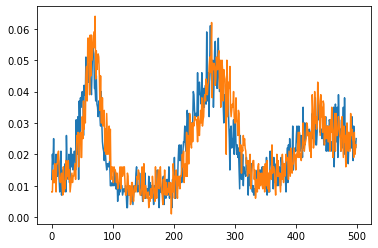

In [1868]:
plt.plot(spikes_rcd[:,:10,:].mean(axis=(1,2)))
plt.plot(spikes_rcd[:,10:,:].mean(axis=(1,2)))

# Play ground for fitting the two methods

These seem to make p values have rough a mean of 0.5
```
{
penalty = 1e3
penalty_pop = 1e0
```
}

In [1862]:
std1 = 10
corr1 = 0.5
std2 = 25
corr2 = 0.9
ntrial = 100
conn = 0.0

ntimes = 10
nfold = 10
penalty = 1e3
penalty_pop = 1e0
num = 20
num_pop = num
num_cp = 3
peaks_max = 15

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    
    test_nll_full = []
    test_nll_nest = []
    test_nll_nestest_pop = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator(std1=std1, corr1=corr1, std2=std2, corr2=corr2, ntrial=ntrial, conn=conn)
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train
        
        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,
                                                 initial_shifts='peaks')
#         model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False, 
#                                                  fix_shifts=best_shifts)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,
                                                 initial_shifts='peaks')
#         model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False,
#                                                 fix_shifts=best_shifts)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")
    print(f"Population nestest:{np.mean(test_nll_nestest_pop):.2f}")
print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")
print(f"p:{np.mean([res[1] for res in result])}")
print(f"p:{np.mean([res[1] for res in result_pop])}")

100%|████████████████████████████████████████████| 10/10 [36:13<00:00, 217.36s/it]

Single neuron full:521.73
Single neuron nest:522.93
Population full:2584.38
Population nest:2584.63
p:4.0459848827125846e-18
p:0.48984375


In [1863]:
result, result_pop

([WilcoxonResult(statistic=21.0, pvalue=3.6669034896259105e-18),
  WilcoxonResult(statistic=21.0, pvalue=3.6669034896259105e-18),
  WilcoxonResult(statistic=0.0, pvalue=1.9482799225479546e-18),
  WilcoxonResult(statistic=0.0, pvalue=1.9482799225479546e-18),
  WilcoxonResult(statistic=24.0, pvalue=4.011921198939099e-18),
  WilcoxonResult(statistic=3.0, pvalue=2.1331613653591172e-18),
  WilcoxonResult(statistic=62.0, pvalue=1.2418628179466936e-17),
  WilcoxonResult(statistic=5.0, pvalue=2.265930530554773e-18),
  WilcoxonResult(statistic=31.0, pvalue=4.946504590755182e-18),
  WilcoxonResult(statistic=19.0, pvalue=3.453336137703006e-18)],
 [WilcoxonResult(statistic=50.0, pvalue=0.9931640625),
  WilcoxonResult(statistic=50.0, pvalue=0.9931640625),
  WilcoxonResult(statistic=12.0, pvalue=0.0654296875),
  WilcoxonResult(statistic=31.0, pvalue=0.65234375),
  WilcoxonResult(statistic=22.0, pvalue=0.3125),
  WilcoxonResult(statistic=36.0, pvalue=0.8125),
  WilcoxonResult(statistic=13.0, pvalue=0

In [1857]:
p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

(0.0, 1.0)

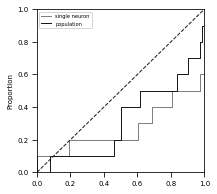

In [1858]:
utils.use_pdf_plot()
plt.subplots(figsize=(3,3))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.plot([0,1], [0,1], '--', color='k')
# 1e5, 0.5e5 connect=0.007

plt.xlim([0,1])
plt.ylim([0,1])

```
{

penalty = 1e0
penalty_pop = 0.5e0
Single neuron full:487.43
Single neuron nest:485.91
Population full:2516.16
Population nest:2517.04
p:0.9999999999811372
p:0.27685546875

penalty = 1e1
penalty_pop = 0.5e1
Single neuron full:492.35
Single neuron nest:491.35
Population full:2532.26
Population nest:2532.21
p:0.9999999748288726
p:0.37724609375

penalty = 1e2
penalty_pop = 0.5e2
Single neuron full:501.33
Single neuron nest:501.08
Population full:2535.60
Population nest:2535.69
p:0.952321695312078
p:0.37890625

penalty = 1e3
penalty_pop = 0.5e3
Single neuron full:511.74
Single neuron nest:511.73
Population full:2538.99
Population nest:2539.24
p:0.6897248222683763
p:0.23115234375

penalty = 1e4
penalty_pop = 0.5e4
Single neuron full:512.30
Single neuron nest:512.30
Population full:2532.22
Population nest:2532.19
p:0.2513382328965973
p:0.1744140625

penalty = 1e5
penalty_pop = 0.5e5
Single neuron full:510.31
Single neuron nest:510.31
Population full:2532.58
Population nest:2532.66
p:0.19500821466345084
p:0.20458984375

penalty = 1e6
penalty_pop = 0.5e6
Single neuron full:512.39
Single neuron nest:512.39
Population full:2546.79
Population nest:2546.81
p:0.18421314299375321
p:0.03203125

```
}

# Sensitivity

Intepretation: The single neuron level model suffers from either overfitting (high variance) or biased estimation, as a consequence of having a big number of coefficients and needing regularization. 

Either one of the following code chuck works. The first one uses MP. 

## Plot fitted filters

In [2288]:
coupling_rcd = []
coupling_pop_rcd = []

std1 = 0
corr1 = 0.0
std2 = 0
corr2 = 0.0
ntrial = 100
conn = 0.0075

ntimes = 2
nfold = 10
penalty = 1e0
penalty_pop = 1e0
num = 20
num_pop = num
num_cp = 3
peaks_max = 15

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    
    test_nll_full = []
    test_nll_nest = []
    test_nll_nestest_pop = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator(std1=std1, corr1=corr1, std2=std2, corr2=corr2, ntrial=ntrial, conn=conn)
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        coupling_rcd_once = []
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )
            
#             coupling_rcd_once.append( np.mean(model_full.get_filter()[1:11], axis=0) )
            coupling_rcd_once += model_full.get_filter()[1:11]
            
            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll
            
        coupling_rcd += coupling_rcd_once

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train
        
        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,)
#                                                  initial_shifts='peaks')
#         model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False, 
#                                                  fix_shifts=best_shifts)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )
    
        coupling_pop_rcd.append(model_full_pop.get_filter()[1])

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,)
#                                                  initial_shifts='peaks')
#         model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False,
#                                                 fix_shifts=best_shifts)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )


100%|██████████████████████████████████████████████| 2/2 [05:22<00:00, 161.02s/it]


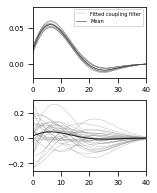

In [2309]:
# Plot only fitted coupling filters
utils.use_pdf_plot()
plt.subplots(figsize=(2.2,2.7))
plt.subplot(2,1,2)
for icoupling, coupling in enumerate(coupling_rcd):
    if np.random.rand()<=0.02:
        plt.plot(coupling, color='grey', lw=0.25)
plt.plot(np.mean(coupling_rcd, axis=0), color='k', lw=1)
plt.xlim([0,40])
# plt.ylim([-0.1,0.1])

plt.subplot(2,1,1)
for icoupling, coupling in enumerate(coupling_pop_rcd):
    if icoupling%1==0:
        if icoupling==0:
            plt.plot(coupling, color='grey', lw=0.25, label='Fitted coupling filter')
        else:
            plt.plot(coupling, color='grey', lw=0.25)
plt.plot(np.mean(coupling_pop_rcd, axis=0), color='k', lw=0.5, label='Mean')
plt.xlim([0,40])
plt.ylim([-0.02,0.08])
plt.yticks([0.0, 0.05])
plt.legend()
plt.tight_layout()
plt.savefig('Figures/Fig2/upper_filters.pdf', format='pdf', dpi=300)

## ** ROC curve

In [ ]:
result, result_pop = GLM.get_ps(ntimes=100, std1=0.0, corr1=0.0, std2=0.0, corr2=0.0, ntrial=100, conn=0.0075)

  0%|                                                     | 0/100 [00:00<?, ?it/s]

In [ ]:
# Plot only ROC

p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

utils.use_pdf_plot()
plt.subplots(figsize=(1.2,1.2))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.plot([0,1], [0,1], '--', color='k')
plt.xlabel('1−specificity')
plt.ylabel('sensitivity')
# 1e5, 0.5e5 connect=0.007

plt.savefig('Figures/Fig2/upper_ROC.pdf', format='pdf', dpi=300)

##  ** Mean p value as a function of trial number

Either two of the code chuck below will work. 

In [ ]:
ntimes = 100
ntrial_list = np.linspace(50,300,6).astype(int)

std1 = 0
corr1 = 0.0
std2 = 0
corr2 = 0.0
# ntrial = 100
conn = 0.0075

result_mat = np.zeros((len(ntrial_list), ntimes))
result_mat_pop = np.zeros((len(ntrial_list), ntimes))

for intrial, ntrial in enumerate(ntrial_list):
    result_temp, result_pop_temp = GLM.get_ps(ntimes=ntimes, std1=std1, corr1=corr1, std2=std2, corr2=corr2, 
                                              ntrial=ntrial, conn=conn)
    for itimes in tqdm(range(ntimes)):
        result_mat[intrial, itimes] = result_temp[itimes][1]
        result_mat_pop[intrial, itimes] = result_pop_temp[itimes][1]

In [ ]:
std1 = 0
corr1 = 0.0
std2 = 0
corr2 = 0.0
# ntrial = 100
conn = 0.007

ntrial_list = np.logspace(np.log10(25),np.log10(400),9).astype(int)

ntimes = 100
nfold = 10
penalty = 1e3
penalty_pop = 1e0
num = 20
num_pop = num
num_cp = 3
peaks_max = 15

tau = 10
num_f_refractory = 4

result_mat = np.zeros((len(ntrial_list), ntimes))
result_mat_pop = np.zeros((len(ntrial_list), ntimes))

for intrial, ntrial in enumerate(ntrial_list):
    for itimes in tqdm(range(ntimes)):

        test_nll_full = []
        test_nll_nest = []
        test_nll_nestest_pop = []
        test_nll_full_pop = []
        test_nll_nest_pop = []
        nll_diff = 0
        nll_diff_pop = 0

        if itimes!=1:
            spikes_rcd = EIF_simulator(std1=std1, corr1=corr1, std2=std2, corr2=corr2, ntrial=ntrial, conn=conn)
        nt, nneuron, ntrial = spikes_rcd.shape

        spike_trains_source = []
        spike_trains_target = []
        time_line = np.arange(nt)

        for ineuron in range(nneuron):
            if ineuron < int(nneuron/2):
                spike_trains_source.append(spikes_rcd[:,ineuron,:])
            else:
                spike_trains_target.append(spikes_rcd[:,ineuron,:])

        kf = KFold(n_splits=nfold)
        for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):

            training_trials = np.array( [False]*ntrial )
            training_trials[train_index] = True
            test_trials = np.logical_not(training_trials)

            ### Single neuron level model
            for output_spike_train in spike_trains_target:

                model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_full.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
                for input_spike_train in spike_trains_source:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
                for input_spike_train in spike_trains_target:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
                model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
                test_nll_full.append( model_full.test(test_trials) )

                model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_nest.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
                for input_spike_train in spike_trains_target:
                    model_nest.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
                model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
                test_nll_nest.append( model_nest.test(test_trials) )
                nll_diff += model_nest.nll - model_full.nll

            ### Population level model
            output_spike_train_pool = np.zeros((nt, ntrial))
            for output_spike_train in spike_trains_target:
                output_spike_train_pool += output_spike_train
            input_spike_train_pool = np.zeros((nt, ntrial))
            for input_spike_train in spike_trains_source:
                input_spike_train_pool += input_spike_train

            model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                      num=num_f_refractory, apply_no_penalty=False)
    #         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
            model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                     warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                     method='mine', penalty=penalty_pop, verbose=False,
                                                     initial_shifts='peaks')
    #         model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
    #                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
    #                                                  method='mine', penalty=penalty_pop, verbose=False, 
    #                                                  fix_shifts=best_shifts)
            test_nll_full_pop.append( model_full_pop.test(test_trials) )

            model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                      num=num_f_refractory, apply_no_penalty=False)
    #         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
            model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                     warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                     method='mine', penalty=penalty_pop, verbose=False,
                                                     initial_shifts='peaks')
    #         model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
    #                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
    #                                                  method='mine', penalty=penalty_pop, verbose=False,
    #                                                 fix_shifts=best_shifts)
            test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
            nll_diff_pop += model_nest_pop.nll - model_full_pop.nll

        result_mat[intrial, itimes] = wilcoxon( test_nll_full, test_nll_nest, alternative='less')[1]
        result_mat_pop[intrial, itimes] = wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less')[1]

 10%|████▎                                      | 1/10 [07:36<1:08:27, 456.43s/it]

In [ ]:
utils.use_default_plot()
xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 1*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single-neuron level model')

yy = (result_mat_pop.mean(axis=1))
yerr = 1*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx+3, yy, yerr=yerr, label='Population level model')

plt.axhline(0.05, ls='--', color='k', label="P=0.05")
plt.yscale("log")
# plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")


In [ ]:
# Plot only mean p value as a function of trial number
utils.use_pdf_plot()
plt.subplots(figsize=(1.5, 1.2))

xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 1*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single')

yy = (result_mat_pop.mean(axis=1))
yerr = 1*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx+3, yy, yerr=yerr, label='Population')

plt.axhline(0.05, ls='--', color='k', label="P=0.05")
plt.yscale("log")
# plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")

plt.savefig('Figures/Fig2/upper_ntrial.pdf', format='pdf', dpi=300)

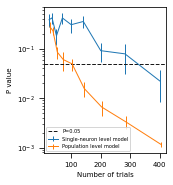

In [2067]:
# Plot only power as a function of trial number
utils.use_pdf_plot()
plt.subplots(figsize=(1.5, 1.2))

xx = ntrial_list
yy = (result_mat<=0.05).mean(axis=1)
plt.plot(xx, yy, label='Single-neuron level model')

yy = (result_mat_pop<=0.05).mean(axis=1)
plt.plot(xx, yy, label='Population level model')

# plt.axhline(0.95, ls='--', color='k', label="P=0.05")
# plt.yscale("log")
# plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("Power")

# plt.savefig('Figures/Fig2/upper_ntrialpower.svg', format='svg', dpi=300)

## ** Plot input currents and spike trains

In [2175]:
spikes_rcd, I_ext = EIF_simulator(std1=0.0, corr1=0.0, std2=0.0, corr2=0.0, ntrial=100, conn=0.007, 
                                  return_current=True)

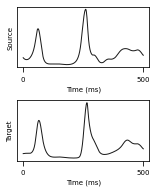

In [2164]:
# plot only currents
utils.use_pdf_plot()
plt.subplots(figsize=(2.2, 2.7))

plt.subplot(2,1,1)
plt.plot(0.1*np.arange(I_ext.shape[0]), I_ext[:,0,0], color='k')
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Source")
plt.subplot(2,1,2)
plt.plot(0.1*np.arange(I_ext.shape[0]), I_ext[:,10,0], color='k')
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Target")
plt.tight_layout()

plt.savefig('Figures/Fig2/upper_currents.pdf', format='pdf', dpi=300)

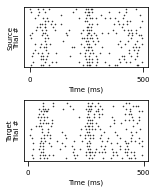

In [2176]:
# Only plot spike trains
utils.use_pdf_plot()
plt.subplots(figsize=(2.2, 2.7))
plt.subplot(2,1,1)
temp = spikes_rcd[:,0,0:20]
for itrial in range(temp.shape[1]):
    for it in range(temp.shape[0]):
        if temp[it,itrial]:
            plt.plot([it], [itrial],".",color='k',markersize=1)
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Source\nTrial #")

plt.subplot(2,1,2)
temp = spikes_rcd[:,10,0:20]
for itrial in range(temp.shape[1]):
    for it in range(temp.shape[0]):
        if temp[it,itrial]:
            plt.plot([it], [itrial],".",color='k',markersize=1)
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Target\nTrial #")
plt.tight_layout()

plt.savefig('Figures/Fig2/upper_spikes.pdf', format='pdf', dpi=300)

# Time warping

## Case with ten data points

In [1862]:
std1 = 10
corr1 = 0.5
std2 = 25
corr2 = 0.9
ntrial = 100
conn = 0.0

ntimes = 10
nfold = 10
penalty = 1e3
penalty_pop = 1e0
num = 20
num_pop = num
num_cp = 3
peaks_max = 15

tau = 10
num_f_refractory = 4

result = []
result_pop_nowarp = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop_nowarp = []
    test_nll_nest_pop_nowarp = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop_nowarp = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator(std1=std1, corr1=corr1, std2=std2, corr2=corr2, ntrial=ntrial, conn=conn)
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train
        
        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,
                                                 initial_shifts='peaks')
#         model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False, 
#                                                  fix_shifts=best_shifts)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,
                                                 initial_shifts='peaks')
#         model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False,
#                                                 fix_shifts=best_shifts)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
        
        
        
        model_full_pop_nowarp = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop_nowarp.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_full_pop_nowarp.add_effect("coupling", raw_input=input_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop_nowarp.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop_nowarp.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
        model_full_pop_nowarp.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        test_nll_full_pop_nowarp.append( model_full_pop_nowarp.test(test_trials) )

        model_nest_pop_nowarp = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop_nowarp.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_nest_pop_nowarp.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop_nowarp.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
        model_nest_pop_nowarp.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        test_nll_nest_pop_nowarp.append( model_nest_pop.test(test_trials) )
        nll_diff_pop_nowarp += model_nest_pop_nowarp.nll - model_full_pop_nowarp.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )
    result_pop_nowarp.append( wilcoxon( test_nll_full_pop_nowarp, test_nll_nest_pop_nowarp, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")
    print(f"Population nestest:{np.mean(test_nll_nestest_pop):.2f}")
print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")
print(f"p:{np.mean([res[1] for res in result])}")
print(f"p:{np.mean([res[1] for res in result_pop])}")

100%|████████████████████████████████████████████| 10/10 [36:13<00:00, 217.36s/it]

Single neuron full:521.73
Single neuron nest:522.93
Population full:2584.38
Population nest:2584.63
p:4.0459848827125846e-18
p:0.48984375


In [2323]:
std1 = 10
corr1 = 0.5
std2 = 25
corr2 = 0.9
ntrial = 100
conn = 0.0

result, result_pop = GLM.get_ps(ntimes=10, std1=std1, corr1=corr1, std2=std2, corr2=corr2, 
                                ntrial=ntrial, conn=conn)

100%|█████████████████████████████████████████████| 10/10 [09:30<00:00, 57.01s/it]


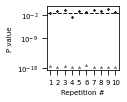

In [2347]:
# Plot only p values
utils.use_pdf_plot()
plt.subplots(figsize=(2.2*0.8, 1.8*0.8))

plt.plot([p[1] for p in result], "^", color='grey', label="Single-neuron level model", markersize=2)
plt.plot([p[1] for p in result_pop], "*", color='k', label="Population level model", markersize=2)
plt.axhline(0.05, ls='--', color='k', lw=1)
# plt.ylim([1e-3, 0.8])
plt.yscale("log")
# plt.legend()
plt.xlabel("Repetition #")
plt.ylabel("P value")
plt.xticks(np.arange(10),np.arange(1,11))
plt.yticks([0.01, 1e-9, 1e-18])
plt.tight_layout()

plt.savefig('Figures/Fig2/lower_pvalues.pdf', format='pdf', dpi=300)

## Mean p value as a function of peak variance

In [2358]:
ntimes = 10
std_apply_list = [0.0, 0.1, 0.2, 0.4, 1]

std1 = 10
corr1 = 0.5
std2 = 25
corr2 = 0.9
ntrial = 100
conn = 0.0

result_mat = np.zeros((len(std_apply_list), ntimes))
result_mat_pop = np.zeros((len(std_apply_list), ntimes))

for i, std_apply in enumerate(std_apply_list):
    if i==4:
        continue
    result_temp, result_pop_temp = GLM.get_ps(ntimes=ntimes, std1=std1*std_apply, corr1=corr1, 
                                              std2=std2*std_apply, corr2=corr2, ntrial=ntrial, conn=conn)
    for itimes in tqdm(range(ntimes)):
        result_mat[i, itimes] = result_temp[itimes][1]
        result_mat_pop[i, itimes] = result_pop_temp[itimes][1]

100%|█████████████████████████████████████████| 10/10 [00:00<00:00, 179243.76it/s]


In [2359]:
for i in range(10):
    result_mat[4, i] = result[i][1]
    result_mat_pop[4, i] = result_pop[i][1]

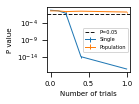

In [2362]:
# Plot only mean p value as a function of trial number
utils.use_pdf_plot()
plt.subplots(figsize=(1.5, 1.2))

xx = std_apply_list
yy = (result_mat.mean(axis=1))
yerr = 1*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single')

yy = (result_mat_pop.mean(axis=1))
yerr = 1*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Population')

plt.axhline(0.05, ls='--', color='k', label="P=0.05")
plt.yscale("log")
# plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")

plt.savefig('Figures/Fig2/lower_std.pdf', format='pdf', dpi=300)

## Plot peak time correlation

In [2270]:
std1 = 10
corr1 = 0.5
std2 = 25
corr2 = 0.9
ntrial = 100
conn = 0.0

bump_center_mean1 = [60, 65]
bump_center_cov1 = np.array([[std1**2, corr1*std1**2], [corr1*std1**2, std1**2]])
bump_center_mean2 = [260, 265]
bump_center_cov2 = np.array([[std2**2, corr2*std2**2], [corr2*std2**2, std2**2]])
bump_centers1 = np.random.multivariate_normal(bump_center_mean1, bump_center_cov1, size=ntrial)
bump_centers2 = np.random.multivariate_normal(bump_center_mean2, bump_center_cov2, size=ntrial)
bump_centers1[bump_centers1>=130] = 130
bump_centers1[bump_centers1<=10] = 10
bump_centers2[bump_centers2>=330] = 330
bump_centers2[bump_centers2<=170] = 170

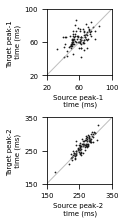

In [2322]:
# Plot only peak time correlation
utils.use_pdf_plot()
plt.subplots(figsize=(2.2*0.8, 3.9*0.8))

plt.subplot(2,1,1)
plt.plot(bump_centers1[:, 0],bump_centers1[:, 1], ".", color='k', markersize=1.5)
plt.axline(xy1=(0, 0), slope=1, color='grey', alpha=0.5)
plt.xlim([20, 100])
plt.ylim([20, 100])
plt.xlabel("Source peak-1 \n time (ms)")
plt.ylabel("Target peak-1 \n time (ms)")
plt.xticks([20,60,100])
plt.yticks([20,60,100])

plt.subplot(2,1,2)
plt.plot(bump_centers2[:, 0],bump_centers2[:, 1], ".", color='k', markersize=1.5)
plt.axline(xy1=(0, 0), slope=1, color='grey', alpha=0.5)
plt.xlim([150, 350])
plt.ylim([150, 350])
plt.xlabel("Source peak-2 \n time (ms)")
plt.ylabel("Target peak-2 \n time (ms)")
plt.xticks([150,250,350])
plt.yticks([150,250,350])
plt.tight_layout()

plt.savefig('Figures/Fig2/lower_corr.pdf', format='pdf', dpi=300)

## ** Plot input currents and spike trains

In [2173]:
spikes_rcd, I_ext = EIF_simulator(std1=10.0, corr1=0.5, std2=25.0, corr2=0.9, ntrial=100, conn=0.0, 
                                  return_current=True)

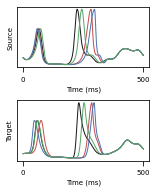

In [2160]:
# plot only currents
utils.use_pdf_plot()
color_list = ['k', 'r', 'b', 'g']

plt.subplots(figsize=(2.2, 2.7))
# plt.subplots(figsize=(6.2, 6.7))

plt.subplot(2,1,1)
for i, color in enumerate(color_list):
    plt.plot(0.1*np.arange(I_ext.shape[0]), I_ext[:,0,i+33], color=color)
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Source")
plt.subplot(2,1,2)
for i, color in enumerate(color_list):
    plt.plot(0.1*np.arange(I_ext.shape[0]), I_ext[:,10,i+33], color=color)
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Target")
plt.tight_layout()

plt.savefig('Figures/Fig2/lower_currents.pdf', format='pdf', dpi=300)

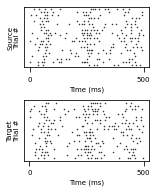

In [2174]:
# Only plot spike trains
utils.use_pdf_plot()
plt.subplots(figsize=(2.2, 2.7))
plt.subplot(2,1,1)
temp = spikes_rcd[:,0,0:20]
for itrial in range(temp.shape[1]):
    for it in range(temp.shape[0]):
        if temp[it,itrial]:
            plt.plot([it], [itrial],".",color='k',markersize=1)
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Source\nTrial #")

plt.subplot(2,1,2)
temp = spikes_rcd[:,10,0:20]
for itrial in range(temp.shape[1]):
    for it in range(temp.shape[0]):
        if temp[it,itrial]:
            plt.plot([it], [itrial],".",color='k',markersize=1)
plt.xticks([0, 500])
plt.yticks([])
plt.xlabel("Time (ms)")
plt.ylabel("Target\nTrial #")
plt.tight_layout()

plt.savefig('Figures/Fig2/lower_spikes.pdf', format='pdf', dpi=300)

# Check for penalty under null

确认0 corr 但是std有的情况下single neuron model会不会出问题: 不会，但是两个Model都bias towards nest model

In [1883]:
std1 = 0
corr1 = 0.0
std2 = 0
corr2 = 0.0
ntrial = 100
conn = 0.0

ntimes = 20
nfold = 10
penalty = 1e3
penalty_pop = 1e0
num = 20
num_pop = num
num_cp = 3
peaks_max = 15

tau = 10
num_f_refractory = 4

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    
    test_nll_full = []
    test_nll_nest = []
    test_nll_nestest_pop = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    if itimes!=1:
        spikes_rcd = EIF_simulator(std1=std1, corr1=corr1, std2=std2, corr2=corr2, ntrial=ntrial, conn=conn)
    nt, nneuron, ntrial = spikes_rcd.shape
    
    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    
    for ineuron in range(nneuron):
        if ineuron < int(nneuron/2):
            spike_trains_source.append(spikes_rcd[:,ineuron,:])
        else:
            spike_trains_target.append(spikes_rcd[:,ineuron,:])
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            for input_spike_train in spike_trains_target:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
            for input_spike_train in spike_trains_target:
                model_nest.add_effect("coupling", raw_input=input_spike_train, num=num_cp, peaks_max=peaks_max, nonlinear=1)
            model_nest.fit(target=output_spike_train, method='mine', penalty=penalty, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train
        
        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_full_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,
                                                 initial_shifts='peaks')
#         model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False, 
#                                                  fix_shifts=best_shifts)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=num, apply_no_penalty=True)
        model_nest_pop.add_effect("coupling", raw_input=output_spike_train_pool, num=num_cp, peaks_max=peaks_max, nonlinear=1)
        model_nest_pop.add_effect('refractory_additive', raw_input=output_spike_train_pool, tau=tau, 
                                  num=num_f_refractory, apply_no_penalty=False)
#         model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=penalty_pop, verbose=False)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
                                                 warp_interval=[[0, 0.15],[0.15, 0.35]], 
                                                 method='mine', penalty=penalty_pop, verbose=False,
                                                 initial_shifts='peaks')
#         model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, 
#                                                  warp_interval=[[0, 0.15],[0.15, 0.35]], 
#                                                  method='mine', penalty=penalty_pop, verbose=False,
#                                                 fix_shifts=best_shifts)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( wilcoxon( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( wilcoxon( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

if ntimes == 1:
    print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
    print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
    print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
    print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")
    print(f"Population nestest:{np.mean(test_nll_nestest_pop):.2f}")
print(f"Single neuron full:{np.mean(test_nll_full):.2f}")
print(f"Single neuron nest:{np.mean(test_nll_nest):.2f}")
print(f"Population full:{np.mean(test_nll_full_pop):.2f}")
print(f"Population nest:{np.mean(test_nll_nest_pop):.2f}")
print(f"p:{np.mean([res[1] for res in result])}")
print(f"p:{np.mean([res[1] for res in result_pop])}")

100%|██████████████████████████████████████████| 20/20 [1:14:04<00:00, 222.21s/it]

Single neuron full:514.01
Single neuron nest:514.03
Population full:2543.54
Population nest:2544.02
p:0.4675363990655549
p:0.346435546875


(0.0, 1.0)

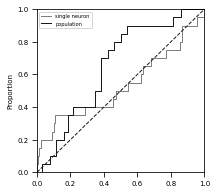

In [1884]:
p = [res[1] for res in result]
p_pop = [res[1] for res in result_pop]

utils.use_pdf_plot()
plt.subplots(figsize=(3,3))
sns.ecdfplot(p, label="single neuron", color='grey')
sns.ecdfplot(p_pop, label="population", color='k')
plt.plot([np.max(p_pop),1], [1,1], color='k')
plt.legend()
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.plot([0,1], [0,1], '--', color='k')
# 1e5, 0.5e5 connect=0.007

plt.xlim([0,1])
plt.ylim([0,1])